# Customer Churn Analysis — KATO Weighted Ensemble Predictions

This notebook demonstrates **binary churn classification** using KATO's prediction ensemble with a **parameter sweep** (441 combinations).

**Approach:**
- Train KATO on customer churn data with two-event sequences (features + utility polarity)
- Sweep all combinations of **RANK_SORT_ALGO** (7), **RECALL_THRESHOLD** (3), **MAX_PREDICTIONS** (3), and **WEIGHTING_METRIC** (7)
- Exploit STM persistence: observe each test sample **once**, then re-query predictions with all 63 server-side configurations
- Evaluate using the **Predictor Operating Characteristic (POC)** chart, maximizing **alpha** for both positive (stay) and negative (churn) classifications
- Top configurations are labeled `P01`–`P08` and charted on the POC

In [1]:
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import json
import math
import time
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
%matplotlib inline

## Configuration

**Fixed parameters** (not swept): `PROBABILITY_METHOD`, `TEMPERATURE`, `CLASSIFICATION_THRESHOLD`

**Swept parameters** (full grid):
1. **RANK_SORT_ALGO** — server-side prediction ranking (10 options)
2. **RECALL_THRESHOLD** — pattern matching strictness (9 options)
3. **MAX_PREDICTIONS** — ensemble size (8 options)
4. **WEIGHTING_METRIC** — client-side aggregation weight (10 options)

In [2]:
# === KATO Connection ===
KATO_URL = "http://kato:8000"  # Docker containers on kato_kato-network
# KATO_URL = "http://localhost:8000"  # Host machine access

# === Dataset ===
TRAIN_FRACTION = 0.8    # Fraction of data for training
TEST_FRACTION = 0.2     # Fraction of data for testing (drawn from remaining samples)

# === Default KATO Prediction Parameters ===
RANK_SORT_ALGO = "potential"
RECALL_THRESHOLD = 0.2
MAX_PREDICTIONS = 10

# === Default Ensemble Weighting ===
WEIGHTING_METRIC = "potential"
PROBABILITY_METHOD = "linear"  # FIXED during sweep
TEMPERATURE = 25.0              # FIXED during sweep
CLASSIFICATION_THRESHOLD = 0.5  # FIXED during sweep

# === Parameter Sweep Grid ===
# Removed: bayesian_likelihood (identical to similarity), snr, evidence
RANK_SORT_OPTIONS = [
    'potential', 'similarity', 'itfdf_similarity',
    'predictive_information', 'bayesian_posterior',
    'bayesian_prior', 'tfidf_score'
]
RECALL_THRESHOLD_OPTIONS = [0.1, 0.4, 0.6]
MAX_PREDICTIONS_OPTIONS = [1, 10, 30]
WEIGHTING_METRIC_OPTIONS = [
    'potential', 'similarity', 'itfdf_similarity',
    'predictive_information', 'bayesian_posterior',
    'bayesian_prior', 'tfidf_score'
]

n_server = len(RANK_SORT_OPTIONS) * len(RECALL_THRESHOLD_OPTIONS) * len(MAX_PREDICTIONS_OPTIONS)
n_total = n_server * len(WEIGHTING_METRIC_OPTIONS)
print(f"Server-side configs: {n_server}")
print(f"Total combos (x weighting metrics): {n_total}")

Server-side configs: 63
Total combos (x weighting metrics): 441


In [3]:
# HTTP session with automatic retry for transient connection errors
http = requests.Session()
retries = Retry(total=3, connect=3, backoff_factor=1.0, allowed_methods=["GET", "POST"])
http.mount("http://", HTTPAdapter(max_retries=retries))
http.mount("https://", HTTPAdapter(max_retries=retries))

def check_kato_health():
    """Check if KATO server is running and healthy"""
    try:
        response = http.get(f"{KATO_URL}/health", timeout=5)
        if response.status_code == 200:
            health_data = response.json()
            print("✅ KATO is healthy!")
            print(f"   Status: {health_data.get('status')}")
            print(f"   Service: {health_data.get('service_name', 'KATO')}")
            if 'uptime_seconds' in health_data:
                print(f"   Uptime: {health_data['uptime_seconds']} seconds")
            return True
        else:
            print(f"❌ KATO health check failed: {response.status_code}")
            return False
    except requests.exceptions.ConnectionError:
        print("❌ Cannot connect to KATO.")
        print("   Troubleshooting:")
        print("   1. Make sure Docker containers are running: docker-compose up -d")
        print("   2. If using 'kato' hostname, ensure Jupyter is on kato_kato-network")
        print("   3. Try changing KATO_URL to 'http://localhost:8000' if running on host")
        return False
    except Exception as e:
        print(f"❌ Error checking KATO health: {e}")
        return False

def verify_network_connectivity():
    """Verify Docker network connectivity"""
    try:
        import socket
        socket.gethostbyname('kato')
        print("✅ Network connectivity: Can resolve 'kato' hostname")
        return True
    except socket.gaierror:
        print("❌ Network connectivity: Cannot resolve 'kato' hostname")
        print("   Either:")
        print("   1. Start Jupyter with --network kato_kato-network")
        print("   2. Change KATO_URL to use 'localhost' instead of 'kato'")
        return False

print("🔍 Checking network connectivity...")
verify_network_connectivity()
print("\n🏥 Checking KATO health...")
check_kato_health()

🔍 Checking network connectivity...
✅ Network connectivity: Can resolve 'kato' hostname

🏥 Checking KATO health...
✅ KATO is healthy!
   Status: healthy
   Service: kato
   Uptime: 403918.62983465195 seconds


True

In [4]:
def create_session(name, max_pattern_length=0, recall_threshold=0.1, node_id=None):
    """Create a new KATO session with specified configuration"""
    if node_id is None:
        import uuid
        node_id = f"churn_node_{uuid.uuid4().hex[:8]}"

    session_config = {
        "node_id": node_id,
        "config": {
            "max_pattern_length": max_pattern_length,
            "recall_threshold": recall_threshold
        },
        "ttl_seconds": 3600,
        "metadata": {"name": name}
    }

    response = http.post(f"{KATO_URL}/sessions", json=session_config)
    if response.status_code == 200:
        session_data = response.json()
        session_id = session_data['session_id']
        print(f"✅ Created session: {name}")
        print(f"   Session ID: {session_id}")
        print(f"   Node ID: {session_data['node_id']}")
        print(f"   Recall threshold: {recall_threshold}")
        return session_id
    else:
        print(f"❌ Failed to create session: {response.status_code}")
        print(response.text)
        return None

def clear_all_memory(session_id):
    """Clear ALL memory (STM and learned patterns) for a session."""
    response = http.post(f"{KATO_URL}/sessions/{session_id}/clear-all", json={})
    if response.status_code == 200:
        print("🧹 Cleared all memory")
        return True
    else:
        print(f"❌ Failed to clear all memory: {response.status_code}")
        return False

def update_session_config(session_id, config):
    """Update session configuration parameters."""
    response = http.post(
        f"{KATO_URL}/sessions/{session_id}/config",
        json={"config": config}
    )
    if response.status_code == 200:
        print(f"✅ Updated config: {config}")
        return True
    else:
        print(f"❌ Failed to update config: {response.status_code}")
        print(response.json())
        return False

## Data Loading & Exploration

In [5]:
churn_df = pd.read_csv('data/churn.csv')
print(f"Dataset: {churn_df.shape[0]} rows, {churn_df.shape[1]} columns")
print(f"\nChurn distribution:")
print(churn_df['Churn?'].value_counts())
print(f"\nChurn rate: {(churn_df['Churn?'] == 'True.').mean():.1%}")
print(f"\nSample rows:")
churn_df.head(3)

Dataset: 3333 rows, 21 columns

Churn distribution:
Churn?
False.    2850
True.      483
Name: count, dtype: int64

Churn rate: 14.5%

Sample rows:


,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.


In [6]:
# Prepare train/test split — non-overlapping samples
feature_columns = [c for c in churn_df.columns if c not in ['Phone', 'Churn?']]
print(f"Features ({len(feature_columns)}): {feature_columns[:5]}...")

train_size = int(len(churn_df) * TRAIN_FRACTION)
test_size = int(len(churn_df) * TEST_FRACTION)

# Training takes the first train_size rows, testing takes the next test_size rows
# This guarantees no overlap between training and testing sets
assert train_size + test_size <= len(churn_df), \
    f"TRAIN_FRACTION ({TRAIN_FRACTION}) + TEST_FRACTION ({TEST_FRACTION}) exceeds dataset size"

churn_train = churn_df[:train_size].to_dict('records')
churn_test = churn_df[train_size:train_size + test_size].to_dict('records')
print(f"Training: {len(churn_train)} samples ({TRAIN_FRACTION:.0%})")
print(f"Testing:  {len(churn_test)} samples ({TEST_FRACTION:.0%})")
print(f"Unused:   {len(churn_df) - train_size - test_size} samples")

Features (19): ['State', 'Account Length', 'Area Code', "Int'l Plan", 'VMail Plan']...
Training: 2666 samples (80%)
Testing:  666 samples (20%)
Unused:   1 samples


## Connect to KATO

In [7]:
# Create session
session_id = create_session("Churn Ensemble", node_id="churn_ensemble", recall_threshold=RECALL_THRESHOLD)

✅ Created session: Churn Ensemble
   Session ID: session-aec336511b774db2afb28cd4c318b0d4-1775575571621
   Node ID: churn_ensemble
   Recall threshold: 0.2


## Training

Train KATO with two-event sequences per customer:
1. **Features** — pipe-delimited strings (`"State|CA"`, `"Account Length|120"`, ...)
2. **Outcome** — utility polarity emotive (`-100` = churned, `+100` = stayed)

In [8]:
clear_all_memory(session_id)

# Disable predictions during training for performance
update_session_config(session_id, {"process_predictions": False})

print("\n🎓 Training on customer churn data...")
for idx, row in enumerate(churn_train):
    http.post(f"{KATO_URL}/sessions/{session_id}/clear-stm", json={})

    # Event 1: Customer features as pipe-delimited strings
    profile_strings = [f"{key}|{value}" for key, value in row.items() if key in feature_columns]
    http.post(f"{KATO_URL}/sessions/{session_id}/observe",
              json={"strings": profile_strings, "vectors": [], "emotives": {}})

    # Event 2: Churn outcome as utility polarity
    utility = -100 if row['Churn?'] == 'True.' else 100
    http.post(f"{KATO_URL}/sessions/{session_id}/observe",
              json={"strings": [], "vectors": [], "emotives": {"utility": float(utility)}})

    http.post(f"{KATO_URL}/sessions/{session_id}/learn", json={})
    if (idx + 1) % 50 == 0:
        print(f"  Trained {idx + 1}/{len(churn_train)} samples...")

print(f"✅ Trained on {len(churn_train)} customer profiles")

# Finalize training: pre-compute entropy and TF vectors across all learned patterns.
# These metrics depend on corpus-level statistics that are only stable after training completes.
response = http.post(f"{KATO_URL}/sessions/{session_id}/finalize-training", json={})
if response.status_code == 200:
    print("✅ Finalized training (pre-computed entropy & TF metrics)")
else:
    print(f"⚠️ Finalize training returned {response.status_code} — predictions will use on-the-fly fallback")

🧹 Cleared all memory
✅ Updated config: {'process_predictions': False}

🎓 Training on customer churn data...
  Trained 50/2666 samples...
  Trained 100/2666 samples...
  Trained 150/2666 samples...
  Trained 200/2666 samples...
  Trained 250/2666 samples...
  Trained 300/2666 samples...
  Trained 350/2666 samples...
  Trained 400/2666 samples...
  Trained 450/2666 samples...
  Trained 500/2666 samples...
  Trained 550/2666 samples...
  Trained 600/2666 samples...
  Trained 650/2666 samples...
  Trained 700/2666 samples...
  Trained 750/2666 samples...
  Trained 800/2666 samples...
  Trained 850/2666 samples...
  Trained 900/2666 samples...
  Trained 950/2666 samples...
  Trained 1000/2666 samples...
  Trained 1050/2666 samples...
  Trained 1100/2666 samples...
  Trained 1150/2666 samples...
  Trained 1200/2666 samples...
  Trained 1250/2666 samples...
  Trained 1300/2666 samples...
  Trained 1350/2666 samples...
  Trained 1400/2666 samples...
  Trained 1450/2666 samples...
  Trained 150

## Ensemble Prediction Logic

Instead of using only the top prediction, we weight **all predictions** in the ensemble:

1. For each prediction `p`, extract its `utility` emotive and its weight from the chosen `WEIGHTING_METRIC`
2. Compute the **weighted average utility**: `sum(w_i * u_i) / sum(w_i)`
3. Map to a **churn probability** using either:
   - **Sigmoid** (default): `P(churn) = 1 / (1 + exp(weighted_utility / temperature))` — smooth, tunable steepness
   - **Linear**: `P(churn) = (1 - weighted_utility / 100) / 2` — simple direct mapping
4. Classify: `P(churn) > threshold` → churn

**Key distinction**: `RANK_SORT_ALGO` controls which predictions KATO returns (server-side). `WEIGHTING_METRIC` controls how we combine them (client-side). These can be tuned independently.

In [9]:
def compute_churn_probability(predictions, weighting_metric=WEIGHTING_METRIC,
                               method=PROBABILITY_METHOD, temperature=TEMPERATURE):
    """Compute churn probability from a KATO prediction ensemble.

    Args:
        predictions: Raw response from /predictions endpoint
        weighting_metric: Which prediction metric to use as weight
        method: "sigmoid" or "linear"
        temperature: Sigmoid steepness (only used if method="sigmoid")

    Returns:
        (churn_prob, weighted_utility, n_preds_used)
    """
    preds = predictions.get('predictions', [])
    if not preds:
        return 0.5, 0.0, 0  # No predictions = maximum uncertainty

    weights = []
    utilities = []
    for p in preds:
        u = p.get('emotives', {}).get('utility')
        w = p.get(weighting_metric, 0)
        if u is not None and w > 0:
            weights.append(w)
            utilities.append(u)

    if not weights:
        return 0.5, 0.0, 0

    total_weight = sum(weights)
    weighted_utility = sum(w * u for w, u in zip(weights, utilities)) / total_weight

    if method == "sigmoid":
        churn_prob = 1 / (1 + math.exp(weighted_utility / temperature))
    else:  # linear
        churn_prob = (1 - weighted_utility / 100) / 2
        churn_prob = max(0.0, min(1.0, churn_prob))

    return churn_prob, weighted_utility, len(weights)


def classify_churn(churn_prob, threshold=CLASSIFICATION_THRESHOLD):
    """Binary classification from probability."""
    return "churn" if churn_prob > threshold else "stay"

## Parameter Sweep

For each test sample we **observe features once**, then re-query KATO predictions across all 63 server-side configurations (7 RANK_SORT_ALGO × 3 RECALL_THRESHOLD × 3 MAX_PREDICTIONS). STM persists across config changes, so each observe is done only once per sample.

For each server response, we also sweep all 7 WEIGHTING_METRIC options client-side (instant, no re-querying). This gives **441 total parameter combinations** evaluated.

In [10]:
# Build the full grid of server-side configs
from itertools import product

server_configs = list(product(RANK_SORT_OPTIONS, RECALL_THRESHOLD_OPTIONS, MAX_PREDICTIONS_OPTIONS))
print(f"Server-side configs to evaluate: {len(server_configs)}")
print(f"Test samples: {len(churn_test)}")
print(f"Total prediction queries: {len(server_configs) * len(churn_test):,}")

actuals = ["churn" if row['Churn?'] == 'True.' else "stay" for row in churn_test]

Server-side configs to evaluate: 63
Test samples: 666
Total prediction queries: 41,958


In [11]:
# Parameter sweep: observe once per sample, query all server configs
# STM persists across config changes — predictions are read-only
import time

# all_classifications[(algo, rt, mp, wm)] = list of 666 predicted labels
all_classifications = {}

t_start = time.time()
for sample_idx, row in enumerate(churn_test):
    # Observe features ONCE per sample
    http.post(f"{KATO_URL}/sessions/{session_id}/clear-stm", json={})
    profile_strings = [f"{key}|{value}" for key, value in row.items() if key in feature_columns]
    http.post(f"{KATO_URL}/sessions/{session_id}/observe",
              json={"strings": profile_strings, "vectors": [], "emotives": {}})

    # Query all 63 server configs with the same STM
    for algo, rt, mp in server_configs:
        http.post(f"{KATO_URL}/sessions/{session_id}/config",
                  json={"config": {
                      "process_predictions": True,
                      "rank_sort_algo": algo,
                      "max_predictions": mp,
                      "recall_threshold": rt
                  }})
        response = http.get(f"{KATO_URL}/sessions/{session_id}/predictions")
        preds = response.json() if response.status_code == 200 else {"predictions": []}

        # Sweep all weighting metrics client-side (instant)
        for wm in WEIGHTING_METRIC_OPTIONS:
            prob, _, _ = compute_churn_probability(
                preds, weighting_metric=wm,
                method=PROBABILITY_METHOD, temperature=TEMPERATURE)
            label = classify_churn(prob, threshold=CLASSIFICATION_THRESHOLD)
            key = (algo, rt, mp, wm)
            if key not in all_classifications:
                all_classifications[key] = []
            all_classifications[key].append(label)

    if (sample_idx + 1) % 20 == 0 or sample_idx == 0:
        elapsed = time.time() - t_start
        rate = (sample_idx + 1) / elapsed
        remaining = (len(churn_test) - sample_idx - 1) / rate
        print(f"  Sample {sample_idx + 1}/{len(churn_test)} "
              f"({elapsed:.0f}s elapsed, ~{remaining:.0f}s remaining)")

elapsed_total = time.time() - t_start
print(f"\nSweep complete: {len(all_classifications)} combos, {elapsed_total:.0f}s total")

  Sample 1/666 (25s elapsed, ~16380s remaining)
  Sample 20/666 (568s elapsed, ~18349s remaining)
  Sample 40/666 (1143s elapsed, ~17892s remaining)
  Sample 60/666 (1716s elapsed, ~17333s remaining)
  Sample 80/666 (2277s elapsed, ~16676s remaining)
  Sample 100/666 (2854s elapsed, ~16151s remaining)
  Sample 120/666 (3417s elapsed, ~15547s remaining)
  Sample 140/666 (3996s elapsed, ~15012s remaining)
  Sample 160/666 (4586s elapsed, ~14503s remaining)
  Sample 180/666 (5153s elapsed, ~13914s remaining)
  Sample 200/666 (5728s elapsed, ~13347s remaining)
  Sample 220/666 (6319s elapsed, ~12809s remaining)
  Sample 240/666 (6889s elapsed, ~12229s remaining)
  Sample 260/666 (7475s elapsed, ~11672s remaining)
  Sample 280/666 (8067s elapsed, ~11121s remaining)
  Sample 300/666 (8650s elapsed, ~10552s remaining)
  Sample 320/666 (9234s elapsed, ~9984s remaining)
  Sample 340/666 (9812s elapsed, ~9408s remaining)
  Sample 360/666 (10382s elapsed, ~8825s remaining)
  Sample 380/666 (11022

## Evaluation — All 441 Configurations

Compute POC alpha (positive and negative) for every parameter combination and rank by combined alpha.

In [12]:
from poc_chart import compute_predictor_metrics

rows = []
for (algo, rt, mp, wm), predicted in all_classifications.items():
    pos_m = compute_predictor_metrics(
        name="", predicted_labels=predicted, true_labels=actuals,
        num_classes=2, mode="positive", positive_classes={"stay"})
    neg_m = compute_predictor_metrics(
        name="", predicted_labels=predicted, true_labels=actuals,
        num_classes=2, mode="negative", positive_classes={"stay"})
    rows.append({
        "rank_sort_algo": algo,
        "recall_threshold": rt,
        "max_predictions": mp,
        "weighting_metric": wm,
        "pos_alpha": pos_m.alpha,
        "neg_alpha": neg_m.alpha,
        "pos_precision": pos_m.precision,
        "neg_precision": neg_m.precision,
        "pos_accuracy": pos_m.accuracy,
        "neg_accuracy": neg_m.accuracy,
    })

eval_df = pd.DataFrame(rows)
eval_df["combined_alpha"] = (eval_df["pos_alpha"] + eval_df["neg_alpha"]) / 2
eval_df = eval_df.sort_values("combined_alpha", ascending=False).reset_index(drop=True)

# Assign alphanumeric labels to top configs
eval_df["label"] = [f"P{i+1:02d}" if i < 99 else f"P{i+1}" for i in range(len(eval_df))]

print(f"Evaluated {len(eval_df)} parameter combinations\n")

print("=" * 90)
print("Top 10 by Combined Alpha (avg of positive + negative)")
print("=" * 90)
cols = ["label", "rank_sort_algo", "recall_threshold", "max_predictions",
        "weighting_metric", "pos_alpha", "neg_alpha", "combined_alpha"]
print(eval_df.head(10)[cols].to_string(index=False, float_format="{:.4f}".format))

print(f"\n{'=' * 90}")
print("Top 10 by Positive Alpha (stay classification)")
print("=" * 90)
top_pos = eval_df.nlargest(10, "pos_alpha")
print(top_pos[cols].to_string(index=False, float_format="{:.4f}".format))

print(f"\n{'=' * 90}")
print("Top 10 by Negative Alpha (churn classification)")
print("=" * 90)
top_neg = eval_df.nlargest(10, "neg_alpha")
print(top_neg[cols].to_string(index=False, float_format="{:.4f}".format))

Evaluated 441 parameter combinations

Top 10 by Combined Alpha (avg of positive + negative)
label   rank_sort_algo  recall_threshold  max_predictions   weighting_metric  pos_alpha  neg_alpha  combined_alpha
  P01 itfdf_similarity            0.1000                1          potential     0.0262     0.0454          0.0358
  P02 itfdf_similarity            0.1000                1         similarity     0.0262     0.0454          0.0358
  P03 itfdf_similarity            0.1000                1   itfdf_similarity     0.0262     0.0454          0.0358
  P04 itfdf_similarity            0.1000                1 bayesian_posterior     0.0262     0.0454          0.0358
  P05 itfdf_similarity            0.1000                1     bayesian_prior     0.0262     0.0454          0.0358
  P06 itfdf_similarity            0.1000                1        tfidf_score     0.0262     0.0454          0.0358
  P07        potential            0.1000                1          potential     0.0218     0.0380     

Best config: P01
  rank_sort_algo:  itfdf_similarity
  recall_threshold: 0.1
  max_predictions:  1
  weighting_metric: potential
  pos_alpha: +0.0262
  neg_alpha: +0.0454
  combined:  +0.0358

Accuracy: 62.3%

              precision    recall  f1-score   support

       churn       0.21      0.47      0.29       109
        stay       0.86      0.65      0.74       557

    accuracy                           0.62       666
   macro avg       0.54      0.56      0.52       666
weighted avg       0.76      0.62      0.67       666



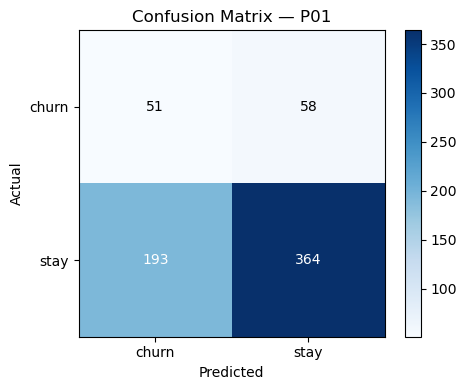

In [13]:
# Confusion matrix for the best config (P01)
best = eval_df.iloc[0]
best_key = (best["rank_sort_algo"], best["recall_threshold"],
            best["max_predictions"], best["weighting_metric"])
best_predicted = all_classifications[best_key]

print(f"Best config: {best['label']}")
print(f"  rank_sort_algo:  {best['rank_sort_algo']}")
print(f"  recall_threshold: {best['recall_threshold']}")
print(f"  max_predictions:  {int(best['max_predictions'])}")
print(f"  weighting_metric: {best['weighting_metric']}")
print(f"  pos_alpha: {best['pos_alpha']:+.4f}")
print(f"  neg_alpha: {best['neg_alpha']:+.4f}")
print(f"  combined:  {best['combined_alpha']:+.4f}")

ensemble_acc = accuracy_score(actuals, best_predicted)
print(f"\nAccuracy: {ensemble_acc:.1%}")
print(f"\n{classification_report(actuals, best_predicted)}")

cm = confusion_matrix(actuals, best_predicted, labels=['churn', 'stay'])
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['churn', 'stay'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['churn', 'stay'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best["label"]}')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.show()

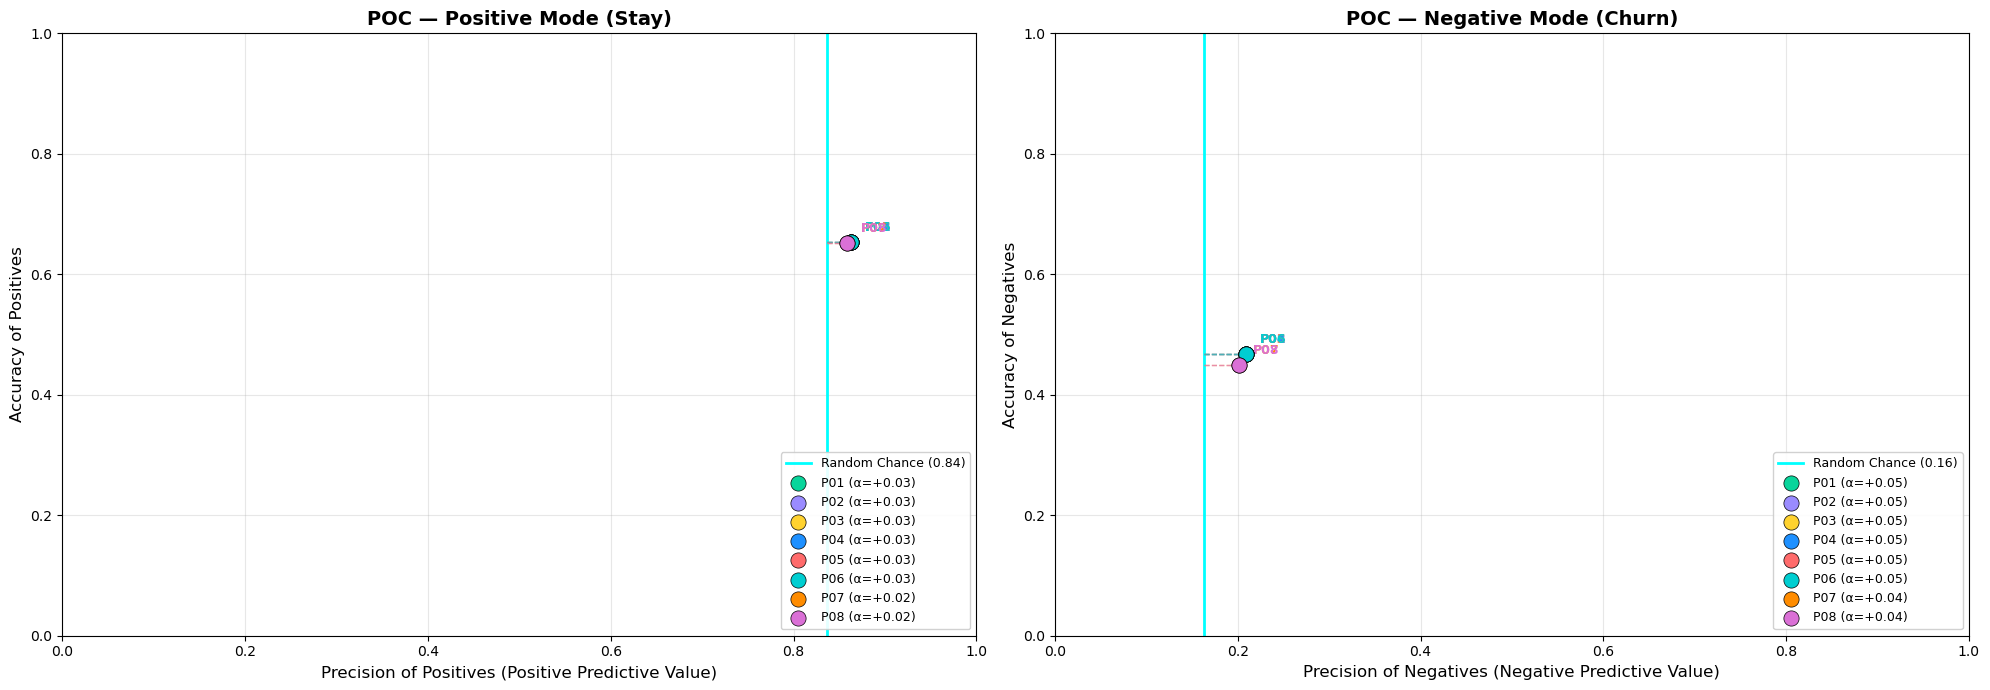


Configuration Reference (Top 8 by combined alpha):
label   rank_sort_algo  recall_threshold  max_predictions   weighting_metric  pos_alpha  neg_alpha  combined_alpha
  P01 itfdf_similarity            0.1000                1          potential     0.0262     0.0454          0.0358
  P02 itfdf_similarity            0.1000                1         similarity     0.0262     0.0454          0.0358
  P03 itfdf_similarity            0.1000                1   itfdf_similarity     0.0262     0.0454          0.0358
  P04 itfdf_similarity            0.1000                1 bayesian_posterior     0.0262     0.0454          0.0358
  P05 itfdf_similarity            0.1000                1     bayesian_prior     0.0262     0.0454          0.0358
  P06 itfdf_similarity            0.1000                1        tfidf_score     0.0262     0.0454          0.0358
  P07        potential            0.1000                1          potential     0.0218     0.0380          0.0299
  P08        potential      

In [14]:
# POC charts with top configurations
from poc_chart import poc_chart

TOP_N = 8
top_configs = eval_df.head(TOP_N)

# Build dict-form inputs for poc_chart
pred_dict_pos = {}
actual_dict_pos = {}
pred_dict_neg = {}
actual_dict_neg = {}

for _, cfg_row in top_configs.iterrows():
    lbl = cfg_row["label"]
    key = (cfg_row["rank_sort_algo"], cfg_row["recall_threshold"],
           cfg_row["max_predictions"], cfg_row["weighting_metric"])
    predicted = all_classifications[key]
    pred_dict_pos[lbl] = predicted
    actual_dict_pos[lbl] = actuals
    pred_dict_neg[lbl] = predicted
    actual_dict_neg[lbl] = actuals

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

poc_chart(pred_dict_pos, actual_dict_pos, num_classes=2,
          mode="positive", positive_classes={"stay"}, ax=ax1,
          title="POC — Positive Mode (Stay)")
poc_chart(pred_dict_neg, actual_dict_neg, num_classes=2,
          mode="negative", positive_classes={"stay"}, ax=ax2,
          title="POC — Negative Mode (Churn)")

plt.tight_layout()
plt.show()

# Reference table
print(f"\nConfiguration Reference (Top {TOP_N} by combined alpha):")
print("=" * 100)
ref_cols = ["label", "rank_sort_algo", "recall_threshold", "max_predictions",
            "weighting_metric", "pos_alpha", "neg_alpha", "combined_alpha"]
print(top_configs[ref_cols].to_string(index=False, float_format="{:.4f}".format))

## Churn Probability Distribution

How well-separated are the predicted churn probabilities between actual churners and stayers?

✅ Updated config: {'process_predictions': True, 'rank_sort_algo': 'itfdf_similarity', 'max_predictions': 1, 'recall_threshold': 0.1}


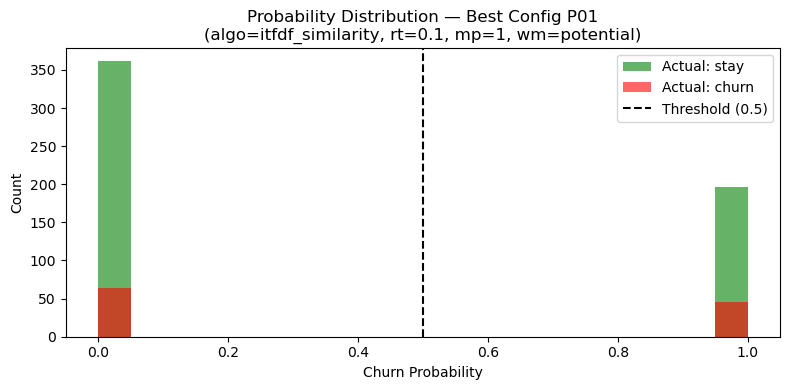

Mean churn prob — actual churners: 0.413
Mean churn prob — actual stayers:  0.352


In [15]:
# Use the best config (P01) for probability distribution analysis
best = eval_df.iloc[0]
best_key = (best["rank_sort_algo"], best["recall_threshold"],
            best["max_predictions"], best["weighting_metric"])
best_predicted = all_classifications[best_key]

# Re-compute probabilities for the best config (need raw predictions for histogram)
# Re-run just the best config to get per-sample probabilities
update_session_config(session_id, {
    "process_predictions": True,
    "rank_sort_algo": best["rank_sort_algo"],
    "max_predictions": int(best["max_predictions"]),
    "recall_threshold": best["recall_threshold"]
})

best_probs = []
for row in churn_test:
    http.post(f"{KATO_URL}/sessions/{session_id}/clear-stm", json={})
    profile_strings = [f"{key}|{value}" for key, value in row.items() if key in feature_columns]
    http.post(f"{KATO_URL}/sessions/{session_id}/observe",
              json={"strings": profile_strings, "vectors": [], "emotives": {}})
    response = http.get(f"{KATO_URL}/sessions/{session_id}/predictions")
    preds = response.json() if response.status_code == 200 else {"predictions": []}
    prob, _, _ = compute_churn_probability(
        preds, weighting_metric=best["weighting_metric"],
        method=PROBABILITY_METHOD, temperature=TEMPERATURE)
    best_probs.append(prob)

results_df = pd.DataFrame({
    "actual": actuals,
    "churn_prob": best_probs,
    "ensemble_pred": best_predicted
})

fig, ax = plt.subplots(figsize=(8, 4))
churn_probs_actual_churn = results_df[results_df['actual'] == 'churn']['churn_prob']
churn_probs_actual_stay = results_df[results_df['actual'] == 'stay']['churn_prob']

ax.hist(churn_probs_actual_stay, bins=20, alpha=0.6, label='Actual: stay', color='green')
ax.hist(churn_probs_actual_churn, bins=20, alpha=0.6, label='Actual: churn', color='red')
ax.axvline(x=CLASSIFICATION_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
           label=f'Threshold ({CLASSIFICATION_THRESHOLD})')
ax.set_xlabel('Churn Probability')
ax.set_ylabel('Count')
ax.set_title(f'Probability Distribution — Best Config {best["label"]}\n'
             f'(algo={best["rank_sort_algo"]}, rt={best["recall_threshold"]}, '
             f'mp={int(best["max_predictions"])}, wm={best["weighting_metric"]})')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean churn prob — actual churners: {churn_probs_actual_churn.mean():.3f}")
print(f"Mean churn prob — actual stayers:  {churn_probs_actual_stay.mean():.3f}")

## Symbol Affinity Analysis

Affinity is a per-symbol cumulative sum of emotive values across all patterns containing the symbol.
Symbols with highly positive utility affinity are key indicators of customer **retention** (stay).
Symbols with highly negative utility affinity are key indicators of customer **churn**.
Symbols near zero are **noise** — not contributing to churn/stay classification.

In [16]:
# Fetch symbol affinity and stats from KATO
affinity_resp = http.get(f"{KATO_URL}/symbols/affinity", headers={'X-Node-ID': 'churn_ensemble'})
affinity_resp.raise_for_status()
stats_resp = http.get(f"{KATO_URL}/symbols/stats", headers={'X-Node-ID': 'churn_ensemble'})
stats_resp.raise_for_status()

affinities = affinity_resp.json()['affinities']
symbol_stats = stats_resp.json()['symbols']

# Build combined DataFrame
rows = []
for symbol, aff in affinities.items():
    stats = symbol_stats.get(symbol, {})
    rows.append({
        'symbol': symbol,
        'frequency': stats.get('frequency', 0),
        'pmf': stats.get('pattern_member_frequency', 0),
        'utility_affinity': aff.get('utility', 0.0)
    })

affinity_df = pd.DataFrame(rows)
print(f"Total symbols with affinity data: {len(affinity_df)}")

Total symbols with affinity data: 9059


In [17]:
# Top 10 symbols with highest positive utility affinity — retention indicators
top_retention = affinity_df.nlargest(10, 'utility_affinity')
print("🟢 Top 10 Retention Indicators (highest positive utility affinity)\n")
print(top_retention[['symbol', 'frequency', 'pmf', 'utility_affinity']].to_string(index=False))

🟢 Top 10 Retention Indicators (highest positive utility affinity)

          symbol  frequency  pmf  utility_affinity
   Int'l Plan|no       2405 2405          187700.0
   VMail Plan|no       1928 1928          131000.0
 VMail Message|0       1928 1928          131000.0
   Area Code|415       1315 1315           95300.0
CustServ Calls|1        959  959           74700.0
  VMail Plan|yes        738  738           60800.0
   Area Code|510        691  691           48900.0
   Area Code|408        660  660           47600.0
CustServ Calls|2        600  600           46600.0
CustServ Calls|0        552  552           41800.0


In [18]:
# Top 10 symbols with most negative utility affinity — churn indicators
top_churn = affinity_df.nsmallest(10, 'utility_affinity')
print("🔴 Top 10 Churn Indicators (most negative utility affinity)\n")
print(top_churn[['symbol', 'frequency', 'pmf', 'utility_affinity']].to_string(index=False))

🔴 Top 10 Churn Indicators (most negative utility affinity)

            symbol  frequency  pmf  utility_affinity
  CustServ Calls|5         50   50           -1200.0
  CustServ Calls|6         16   16            -400.0
    Eve Mins|205.7          3    3            -300.0
    Intl Mins|13.9         11   11            -300.0
  Intl Charge|3.75         11   11            -300.0
    Day Mins|167.1          2    2            -200.0
  Eve Charge|20.86          2    2            -200.0
Night Charge|12.81          2    2            -200.0
    Day Mins|239.7          2    2            -200.0
    Day Mins|303.9          2    2            -200.0


In [19]:
# Top 10 symbols closest to zero affinity — noise/non-contributing
affinity_df['abs_utility'] = affinity_df['utility_affinity'].abs()
noise = affinity_df.nsmallest(10, 'abs_utility')
print("⚪ Top 10 Noise Symbols (utility affinity nearest zero)\n")
print(noise[['symbol', 'frequency', 'pmf', 'utility_affinity']].to_string(index=False))

⚪ Top 10 Noise Symbols (utility affinity nearest zero)

            symbol  frequency  pmf  utility_affinity
  Night Mins|105.4          2    2               0.0
  Day Charge|25.18          2    2               0.0
    Eve Mins|209.4          6    6               0.0
   Eve Charge|14.2          6    6               0.0
    Eve Mins|264.8          2    2               0.0
    Day Mins|265.6          2    2               0.0
  Eve Charge|18.22          2    2               0.0
Night Charge|12.16          2    2               0.0
  Night Mins|193.1          2    2               0.0
    Day Mins|130.5          2    2               0.0


## Conclusion

### 1. MAX_PREDICTIONS=1 Dominates — The Ensemble Hurts

The most striking finding: **every top configuration uses `max_predictions=1`**. The weighted ensemble approach is counterproductive — additional predictions add noise that dilutes the signal from the best match. The single top-1 prediction carries the most information.

This also means **WEIGHTING_METRIC is irrelevant** in the winning configs. P01 through P06 all have identical alpha values despite different weighting metrics, because there is nothing to weight when only one prediction is returned.

### 2. Alpha Values Are Very Small — Barely Beating Random Chance

The best combined alpha is **+0.036**. On the POC charts, all points cluster very close to the baseline:
- **Positive mode (stay)**: precision ~ 0.86 vs baseline 0.84 &rarr; &alpha; = +0.03
- **Negative mode (churn)**: precision ~ 0.21 vs baseline 0.16 &rarr; &alpha; = +0.05

The model is only marginally better than guessing based on class frequency.

### 3. RECALL_THRESHOLD=0.1 Wins — Permissive Matching Is Better

The lowest recall threshold universally performs best, meaning KATO needs the broadest possible pattern matching to find useful signals in this data.

### 4. RANK_SORT_ALGO Is the Only Differentiating Parameter

`itfdf_similarity` is the clear winner, followed by `potential`. TF-IDF-based similarity upweights rare features, which is critical for detecting the minority churn class (14.5% base rate).

### 5. Probability Distribution — Weak Class Separation

The histogram shows a bimodal distribution (predictions cluster at ~0.0 and ~1.0), but **both churners and stayers appear in both clusters**. The class mixtures within each cluster are poorly separated:
- Mean churn probability for actual churners: **0.413**
- Mean churn probability for actual stayers: **0.352**
- Separation: only **0.061**

### 6. Confusion Matrix — High False-Positive Rate

| | Predicted Churn | Predicted Stay |
|---|---|---|
| **Actual Churn** | 51 (TP) | 58 (FN) |
| **Actual Stay** | 193 (FP) | 364 (TN) |

The model catches 47% of churners but at the cost of misclassifying 35% of stayers as churners (churn precision = 21%).
A business may decide that this is an acceptable tradeoff since it costs less to retain a customer who will not churn versus lose a customer who will churn.

### 7. Symbol Affinity Confirms Business Intuition

- **Top retention signal**: `Int'l Plan|no` (affinity +187,700) — no international plan = likely to stay
- **Top churn signal**: `CustServ Calls|5` (affinity -1,200) — frequent service calls = churning
- `CustServ Calls|1-2` are retention indicators while `CustServ Calls|5-6` are churn indicators — a clear dose-response relationship

### Possible Next Steps to Improve Alpha

1. **Feature engineering** — Bin continuous features (e.g., `Day Mins|High` instead of `Day Mins|265.1`) to reduce symbol sparsity. Many symbols appear only 2-3 times, limiting pattern generalization.
2. **Investigate the ensemble failure** — Why does weighting multiple predictions hurt? The weighting formula or the linear probability mapping may need rethinking.
3. **Classification threshold tuning** — Given the 85.5/14.5 class imbalance, 0.5 may not be optimal. A lower threshold could improve churn recall without as much precision loss.
4. **Randomized train/test split** — The current split is sequential (first 80% train, next 20% test) rather than randomized, which could introduce temporal bias if the data has any ordering.